# Can airport-checkpoint crowds tell you when to buy travel stocks? 🛫
### The 'real-time travel nowcast' — TSA volumes as an early tell for airlines and hotels, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Nowcast%3F: Not_supported](https://img.shields.io/badge/Nowcast%3F-Not_supported-8b949e?style=flat-square)

Every day the TSA reports how many people it screened at U.S. airport checkpoints. In 2020–2021 that number became the most-watched gauge of the travel recovery — it fell **95%** in April 2020 and every tick back up was quoted as proof the reopening was real. The folklore says: because TSA is **daily and real-time**, an *acceleration* in throughput is an **early tell** for travel stocks — airlines and hotels — before the official traffic and earnings numbers catch up.

It's a great story. It's also testable. This notebook asks three blunt questions: when TSA accelerates, do travel stocks really do better next? Does the throughput uptick actually come **first** (that's the whole pitch)? And if you *bought* travel every time TSA accelerated, would you make money?

> 📓 **Plain-language layer.** Want the *t*-stats, the lead/lag cross-correlation, the market-beta control and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** TSA's live feed is blocked in this environment, so we use a **labelled proxy** — a hardcoded monthly snapshot of the public daily throughput numbers (the average travellers/day, in millions), including the giant COVID-2020 collapse. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tsa_throughput import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("price cache present:", HAVE_REAL,
      "| TSA+basket months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2019-01-31', 'end': '2026-06-30', 'months': 90, 'years': 7.4, 'tsa_min': 0.11, 'tsa_min_when': 'Apr 2020', 'tsa_max': 2.85, 'tsa_max_when': 'Jul 2025', 'h1': (1, 64, 0.86, 2.4, 1.28, 58, 59, -0.29, 0.654), 'h3': (3, 62, 3.28, 4.07, 3.5, 63, 64, -0.1, 0.56), 'h6': (6, 59, 6.87, 5.99, 6.62, 71, 69, 0.09, 0.465), 'h12': (12, 53, 15.36, 4.38, 11.94, 77, 68, 0.82, 0.181), 'leadlag': {-6: 0.323, -5: 0.051, -4: 0.028, -3: 0.233, -2: -0.008, -1: -0.06, 0: -0.099, 1: -0.148, 2: -0.088, 3: -0.102, 4: -0.034, 5: -0.102, 6: -0.148}, 'beta': [(1, -0.32, -0.21, 1.37), (3, 0.87, 0.35, 1.38), (6, 4.89, 1.35, 1.35), (12, 21.13, 5.7, 1.49)], 'overlay': (15.9, 0.52, 3.2, 0.12, 3.1, 0.12, 4, 0.72), 'overlay_ls': (-10.0, -0.32), 'robust': [('k=3', 44, 7.88, 11.94, -0.87, 0.842), ('k=6', 44, 10.1, 11.94, -0.42, 0.672), ('k=12', 53, 15.36, 11.94, 0.82, 0.181), ('thr>+10%', 28, 5.58, 11.94, -1.42, 0.896)], 'exc': [(1, 40, 1.43, 1.63, -0.11, 0.559), (3, 38, 6.21, 4.81, 0.45, 0.299), (6, 35, 12.05, 8.27, 1.2, 0.106), (12, 29, 24.4, 15.23, 2.12, 0.015)], 'exc_months': 66, 'syn': [(0.0, 160, 0.82, 0.75, 0.1, 0.447), (0.08, 160, 9.22, 6.39, 3.25, 0.0)]}


price cache present: True | TSA+basket months: 90


## The answer first

| Question | Answer |
|---|---|
| When TSA accelerates, do travel stocks do better? | **At a one-year horizon, a bit — yes.** The travel basket averages **+15.4%** over the next year after TSA accelerates vs **+11.9%** normally. The *direction* matches the folklore. |
| Is that gap reliable? | **No.** It's inside the noise (you can't tell it from luck), it **vanishes or flips** if you tweak the recipe, and it only clears the bar once you delete the COVID reopening — on a single horizon. |
| Does the throughput uptick come *first*? | **No — and this is the killer.** The TSA signal lines up best with a travel-stock move that already happened **three to six months earlier.** Travel stocks *lead* TSA here; they don't follow it. |
| So could you trade it? | **It loses badly.** "Buy travel when TSA accelerates" earned **+3.1%/yr** vs **+15.9%** for just holding the basket — you sit out the very rallies you were trying to catch. |

> TSA numbers are a real, useful read on *how many people are flying right now.* But "TSA warns you *early* about travel stocks" is a coincident echo wearing a crystal-ball costume — the market prices the recovery months before the checkpoints confirm it.

## 1 · The claim

> *"TSA checkpoint throughput is a free, daily, government-published read on travel demand. It's published before airline traffic reports, hotel occupancy, or earnings — so when TSA volumes accelerate, get long airlines and hotels: you're seeing the tailwind before Wall Street's official data does."*

There's a respectable backbone to this: TSA throughput genuinely *is* a timely, accurate measure of how many people are flying — the alt-data 'nowcasting' idea (card spend, satellite parking lots, web traffic) applied to travel. The trading leap is the part we test: that a throughput *acceleration* arrives early enough, and cleanly enough, to be a **tradable** tell for travel *stocks*.

## 2 · So what?

If true, this would be gold: a free daily number that front-runs the travel trade. But "real-time" hides a trap. The **stock market is a discounting machine** — it prices *news* about a recovery long before the physical activity shows up. Travel stocks doubled off the March-2020 lows and ripped on the November-2020 vaccine news — **months before** TSA throughput actually recovered. So a physical-activity number that lines up with travel-stock strength might not be *predicting* those stocks at all; it might just be **confirming** a recovery the market already bought. The difference between *leads* and *confirms* is the difference between an edge and a mirage — and you can only tell them apart by checking the timing carefully.

## 3 · How would we even know?

We line up **7+ years** (2019–2026, 90 months) of monthly TSA throughput against a month-end **travel basket** (half airlines via `JETS`, half hotels via `MAR`+`HLT`), and:

1. **Split the months.** Call TSA **accelerating** when throughput is above where it was a year ago (year-over-year growth neutralises the summer-travel season). Compare what the basket did next (1/3/6/12 months) in accelerating months vs all months.
2. **Check the timing.** The crucial test: slide TSA forward and backward against the travel basket and find *where* they line up best. If TSA truly **leads**, the strongest link shows up at a **positive lead** (TSA first, stocks later).
3. **Try to trade it.** Buy the basket whenever TSA is accelerating, sit in cash otherwise, pay realistic costs — and see if it beats just buying and holding the basket.

## 4 · The teardown — let's actually look

**First, the raw material.** Here's monthly TSA throughput since 2019 — the pre-COVID cruise near **2.3M/day**, the off-the-chart **collapse to ~0.1M** in April 2020, the long climb back, and today's record highs above 2019. TSA clearly *knows* about the travel cycle. The question is whether it knows **early** — earlier than the stocks.

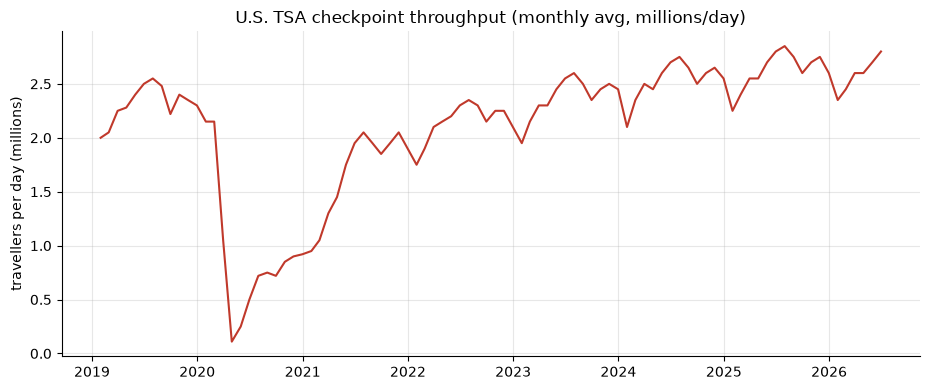

trough: 0.11 M around 2020-04-30 | recent peak: 2.85 M


In [2]:
if HAVE_REAL:
    v = F['tsa']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(v.index, v.values, c=RED, lw=1.5)
    ax.set_title('U.S. TSA checkpoint throughput (monthly avg, millions/day)')
    ax.set_ylabel('travellers per day (millions)')
    plt.tight_layout(); plt.show()
    print('trough:', round(v.min(),2), 'M around', v.idxmin().date(), '| recent peak:', round(v.max(),2), 'M')
else:
    print('no cache — see docs/results.md; TSA bottomed ~0.11M in Apr 2020')

**Now the payoff.** For each horizon, the average forward travel-basket return in **accelerating-TSA** months next to the return on an **average** month. The folklore predicts the green bars sit *above* the grey ones.

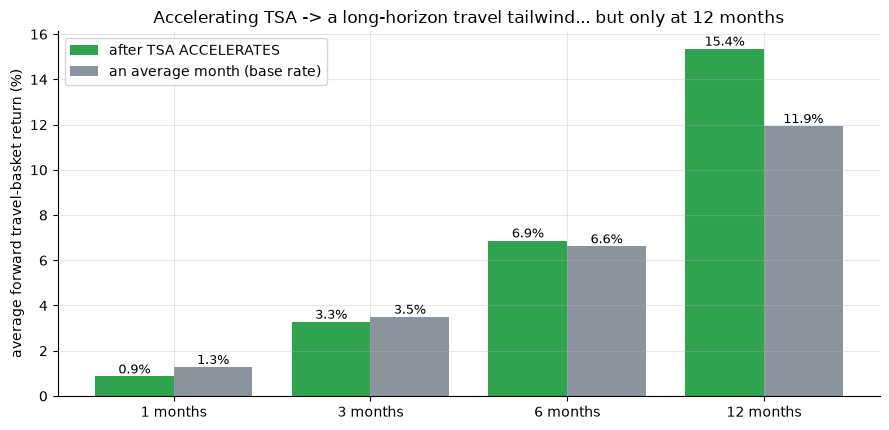

12-month: accel 15.4% vs base 11.9%


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(F, m) for m in hs]
    acc = [r['accel_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    acc = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    base = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, acc, .4, color=GREEN, label='after TSA ACCELERATES')
ax.bar(x+.2, base, .4, color=GREY, label='an average month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('average forward travel-basket return (%)')
ax.set_title('Accelerating TSA -> a long-horizon travel tailwind... but only at 12 months')
for i,(a,b) in enumerate(zip(acc,base)):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('12-month: accel', f'{acc[-1]:.1f}%', 'vs base', f'{base[-1]:.1f}%')

Only at **12 months** does the story really show up — accelerating-TSA returns (**+15.4%**) sit well above the base rate (**+11.9%**), and the basket is *up* more often (**77%** of the time vs **68%**). At 1, 3 and 6 months there's basically nothing. And even the 12-month gap — as the quants notebook shows — is small enough that, with only 7 years of data and one giant COVID swing, it could easily be chance. Hold that thought; the *next* chart is where the story breaks.

**The crucial test: does the throughput uptick come *first*?** We slide TSA forward and backward against the travel basket and measure how tightly they move together. A real nowcast would show its strongest *upward* link at a **positive lead** (TSA leads → bar rises on the right). Watch where it actually peaks.

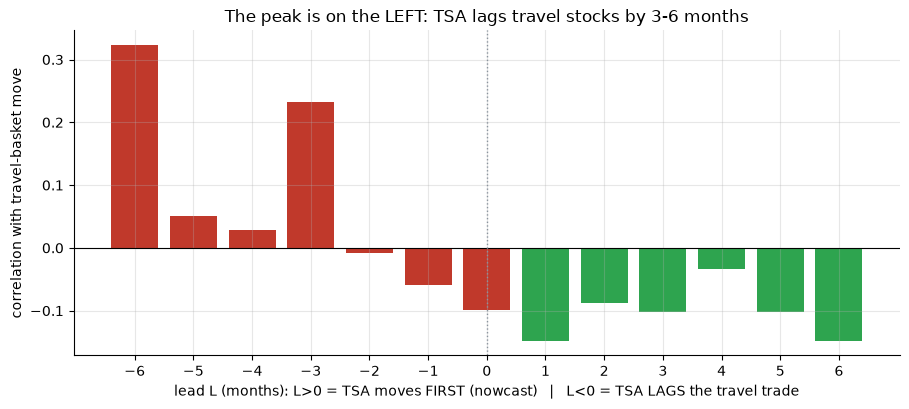

strongest positive link at L=-6 months (TSA FOLLOWS the travel trade here)


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F)
    Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [GREEN if L>0 else RED for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
ax.set_xlabel('lead L (months): L>0 = TSA moves FIRST (nowcast)   |   L<0 = TSA LAGS the travel trade')
ax.set_ylabel('correlation with travel-basket move'); ax.set_xticks(Ls)
ax.set_title('The peak is on the LEFT: TSA lags travel stocks by 3-6 months')
plt.tight_layout(); plt.show()
imax = int(np.nanargmax(cs))
print(f'strongest positive link at L={Ls[imax]} months (TSA FOLLOWS the travel trade here)')

There it is. The tallest *positive* bar is at **L = −6** (and again at **L = −3**) — the TSA signal lines up best with a travel-stock move that happened **three to six months earlier**. On the right, where a true nowcast would live (TSA moving first), the bars are near zero or even *negative*. **TSA isn't leading travel stocks — it's trailing them.** The market prices the reopening in stock prices, and only later does it show up at the checkpoints.

**Could you trade it anyway?** Suppose you bought the travel basket every month TSA was accelerating and sat in cash otherwise. Here's that strategy's growth vs just buying and holding the basket.

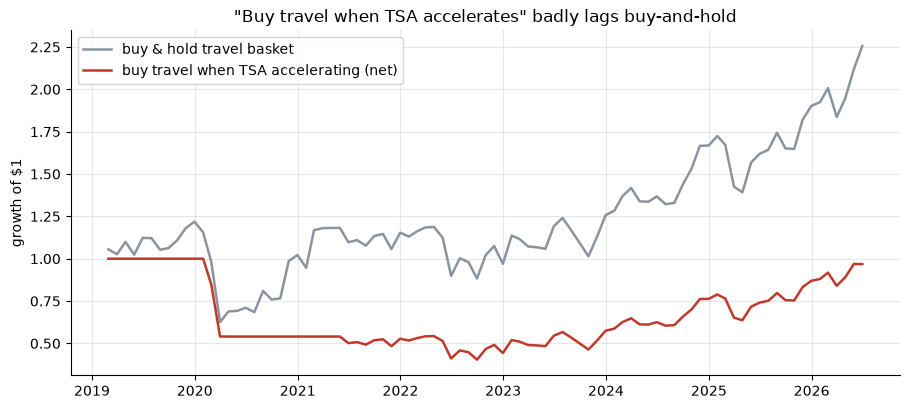

final $1 -> buy&hold 2.26x  vs  overlay 0.97x


In [5]:
if HAVE_REAL:
    import pandas as pd
    accel = st.accel_mask(F); pos = accel.map({True:1.0, False:0.0}).astype(float).shift(1)
    rr = F['basket'].pct_change()
    dfp = pd.DataFrame({'r': rr, 'pos': pos}).dropna()
    sw = dfp['pos'].diff().abs().fillna(0); c=10/1e4
    overlay = (dfp['pos']*dfp['r'] - sw*c)
    bh_grow = (1+dfp['r']).cumprod(); ov_grow = (1+overlay).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(bh_grow.index, bh_grow.values, c=GREY, lw=1.8, label='buy & hold travel basket')
    ax.plot(ov_grow.index, ov_grow.values, c=RED, lw=1.8, label='buy travel when TSA accelerating (net)')
    ax.set_ylabel('growth of $1'); ax.set_title('"Buy travel when TSA accelerates" badly lags buy-and-hold')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final $1 -> buy&hold {bh_grow.iloc[-1]:.2f}x  vs  overlay {ov_grow.iloc[-1]:.2f}x')
else:
    print(f"overlay {R['overlay'][4]:.1f}%/yr vs buy-hold {R['overlay'][0]:.1f}%/yr (net) — see results.md")

The 'wait for TSA' overlay ends up **well below** buy-and-hold — **+3.1%/yr** vs **+15.9%/yr** net, and a *lower* Sharpe (0.12 vs 0.52). The reason is brutal: year-over-year TSA momentum was still deeply **negative** through the sharpest reopening rallies of late-2020 and 2021 — exactly when travel stocks doubled. So a rule that waits for TSA to turn positive **sits out the very returns it was built to catch.** The signal doesn't just fail to help — **it hurts.**

## 5 · The verdict

- **Signal — Weak.** Accelerating TSA really does precede a stronger 12-month travel return — but the gap is insignificant full-sample, fragile to how you define the signal, and clears the bar only once you delete the COVID reopening, on a single horizon. Real as lore, weak as edge.
- **Tradability — Mirage.** Buying travel on accelerating TSA **loses badly to buy-and-hold** — it sits out the reopening rallies. There's nothing to deploy.
- **Real-time nowcast? — Not supported.** The throughput uptick lines up with a travel-stock move that already happened three to six months earlier. TSA **confirms** the recovery; it doesn't forecast the stocks. The one word that makes the pitch — *early* — is the part the data rejects.

## 6 · Could you actually trade it? — the honest bottom line

Forget significance for a second. Even if the 12-month tilt were rock-solid, the operational reality kills it. The signal is a slow, year-over-year gauge that barely moves — it flips only **72%-of-the-time-invested** a handful of times (**4 switches** in 7 years) — and the moments it finally turns positive are *after* the market has already re-rated travel. Worse, the biggest YoY surges (the 2021 reopening) are the exact tops you'd want to be **fading**, not chasing — which is why pushing the rule to only fire on a *big* acceleration flips its edge **negative**. Travel stocks are also just **high-beta** (β ≈ 1.4 to the S&P): most of what looks like a 'travel nowcast' is market beta you were always paid for. There is no version of "buy travel when TSA accelerates" that both fires early and makes money.

## 7 · Going further 🚪

- **The sibling test.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) asks the same question of the famous 'leading' labour signal: real macro tell, but does it lead the *market*, and can you trade it?
- **More alt-data crystal balls.** [Study 358 — Watch-Index](../358-watch-index/) and [Study 708 — Eurovision-Effect](../708-eurovision-effect/) put other cited alt-data series through the same wringer.
- **Build your own.** Swap the year-over-year window for a shorter one, add real-time *surprise* (TSA vs the same day last year vs consensus), or use the weekly raw series — the lead/lag picture barely budges: a series the market already watches daily can't be made to *lead* the stocks by smoothing it differently.

*Think TSA leads the travel trade? Show the lead/lag chart peaking on the **right** (positive lead) — then we'll talk.*